## House Price Prediction

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
df = pd.read_csv('train.csv')

In [6]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [8]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Differentiate categorical and numerical Column

In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Numerical: 38
Categorical: 43


In [11]:
num_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [12]:
cat_cols

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

### Missing Values

In [13]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [14]:
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head())


MSZoning
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Street
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Alley
Alley
Grvl    50
Pave    41
Name: count, dtype: int64

LotShape
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

LandContour
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

Utilities
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

LotConfig
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

LandSlope
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

Neighborhood
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Name: count, dtype: int64

Condition1
Condition1
Norm      1260
Feedr       81
Artery      48
RRAn        26
PosN        19
Name: count, dtype: int64

Condition2
Conditio

### Correlation Column for House Price

In [15]:
corr = df.corr(numeric_only=True)

corr["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

In [16]:
drop_cols = [
    'PoolQC',
    'MiscFeature',
    'Alley',
    'Fence'
]

df.drop(columns=drop_cols, inplace=True)

In [17]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_12168\485167027.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_12168\485167027.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

In [18]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_12168\2422164989.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [19]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

In [20]:
df['TotalBath'] = (
    df['FullBath']
    + 0.5*df['HalfBath']
    + df['BsmtFullBath']
    + 0.5*df['BsmtHalfBath']
)

In [21]:
df['TotalArea'] = (
    df['GrLivArea']
    + df['TotalBsmtSF']
)

In [22]:
df = pd.get_dummies(df, drop_first=True)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [24]:
import pandas as pd

train = pd.read_csv("train.csv")

X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]

In [25]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

numeric_transformer = SimpleImputer(strategy='median')

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [28]:
print (r2_score(y_test, lr_pred))

0.8720483670512569


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [30]:
print (r2_score(y_test, rf_pred))

0.8941513442361082


In [32]:
from xgboost import XGBRegressor

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [34]:
r2 = r2_score(y_test, xgb_pred)

### XGB Model gives the 0.90 accuracy score


# Try Performing the EDA 

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings, math
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm, skew

from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                   BayesianRidge)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               AdaBoostRegressor, ExtraTreesRegressor,
                               StackingRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import xgboost as xgb
# import lightgbm as lgb

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
np.random.seed(SEED)
print("✅ All libraries imported successfully")


✅ All libraries imported successfully


In [2]:
train = pd.read_csv('train.csv')
print(f"Train shape: {train.shape}")
train.head()


Train shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
print("=== Dataset Info ===")
train.info()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

In [6]:
print("=== Basic Statistics ===")
train.describe()

=== Basic Statistics ===


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## EDA

## Target column (train[salesprice])

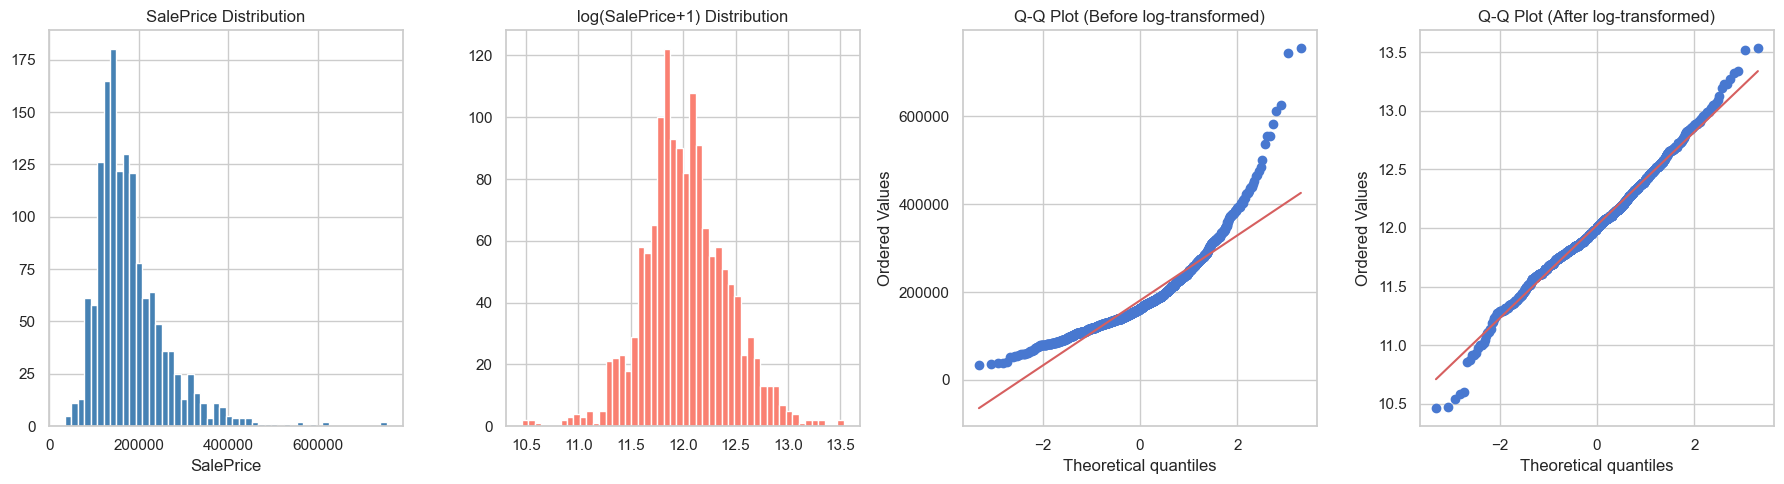

Skewness (original)     : 1.8829
Skewness (log-transform): 0.1213


In [23]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice Distribution')
axes[0].set_xlabel('SalePrice')



# After log transform
log_price = np.log1p(train['SalePrice'])
axes[1].hist(log_price, bins=50, color='salmon', edgecolor='white')
axes[1].set_title('log(SalePrice+1) Distribution')


# Q-Q plot
stats.probplot(train['SalePrice'], plot=axes[2])
axes[2].set_title('Q-Q Plot (Before log-transformed)')

stats.probplot(log_price, plot=axes[3])
axes[3].set_title('Q-Q Plot (After log-transformed)')

plt.tight_layout()
plt.show()

print(f"Skewness (original)     : {train['SalePrice'].skew():.4f}")
print(f"Skewness (log-transform): {log_price.skew():.4f}")

## Missing Values

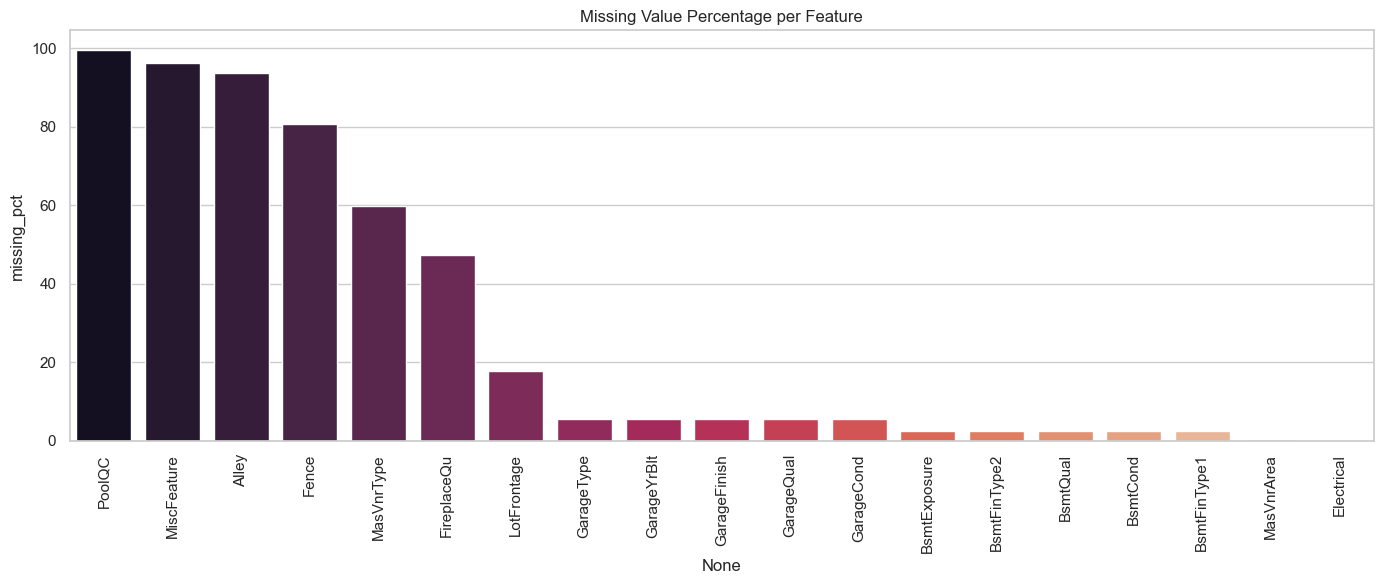

In [7]:
missing = train.isnull().sum()
missing =missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train)*100).round(2)

missing_df=pd.DataFrame({
    "Missing":missing,
    "missing_pct":missing_pct
})

plt.figure(figsize=(14, 6))
sns.barplot(x=missing_df.index, y='missing_pct', data=missing_df, palette='rocket')
plt.xticks(rotation=90)
plt.title('Missing Value Percentage per Feature')
plt.tight_layout()
plt.show()

## Corralation HeatMap 
### (Top 15 columns)

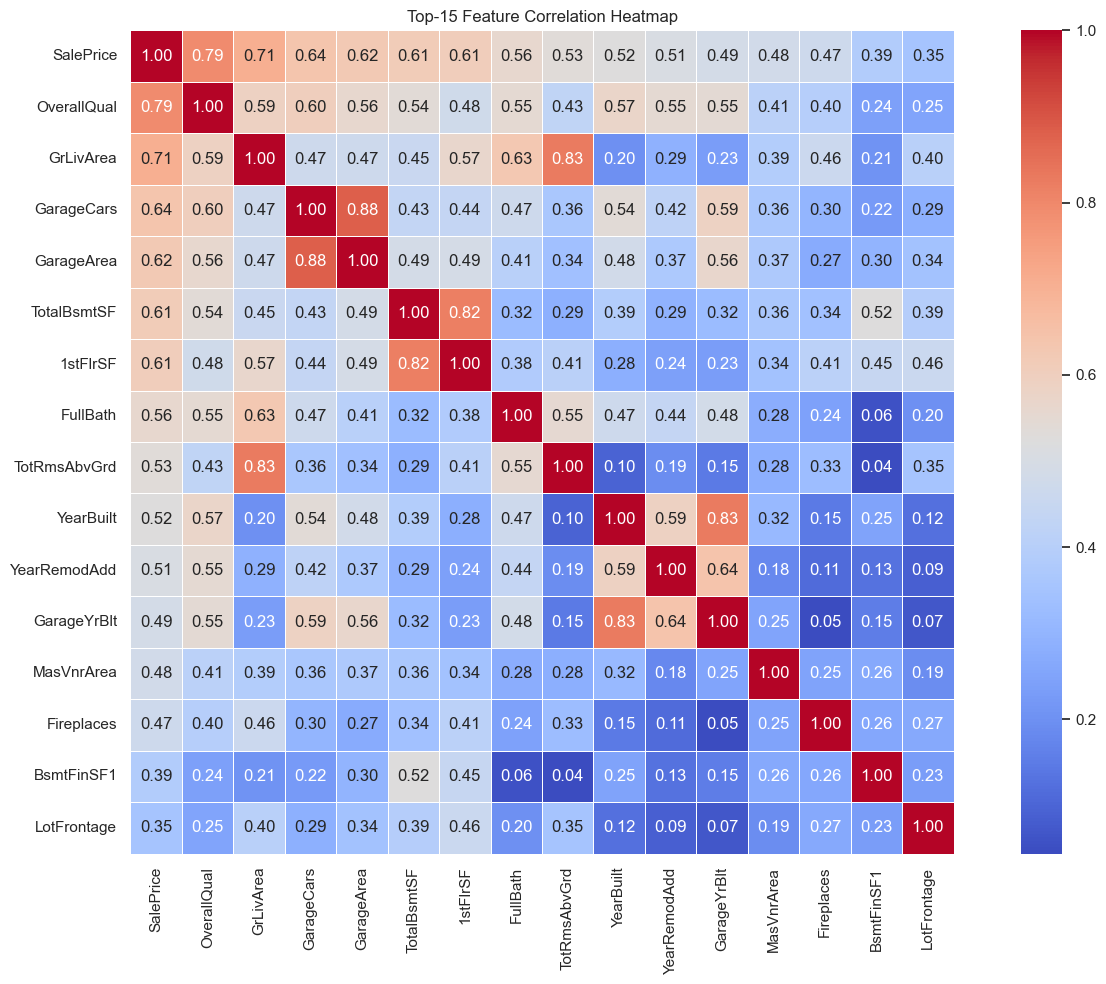

In [ ]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[num_cols].corr()

# Top 15 features correlated with SalePrice
top_corr = corr['SalePrice'].abs().sort_values(ascending=False).head(16).index
plt.figure(figsize=(14, 10))

sns.heatmap(train[top_corr].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', square=True, linewidths=.5)
plt.title('Top-15 Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


## Numerical Data

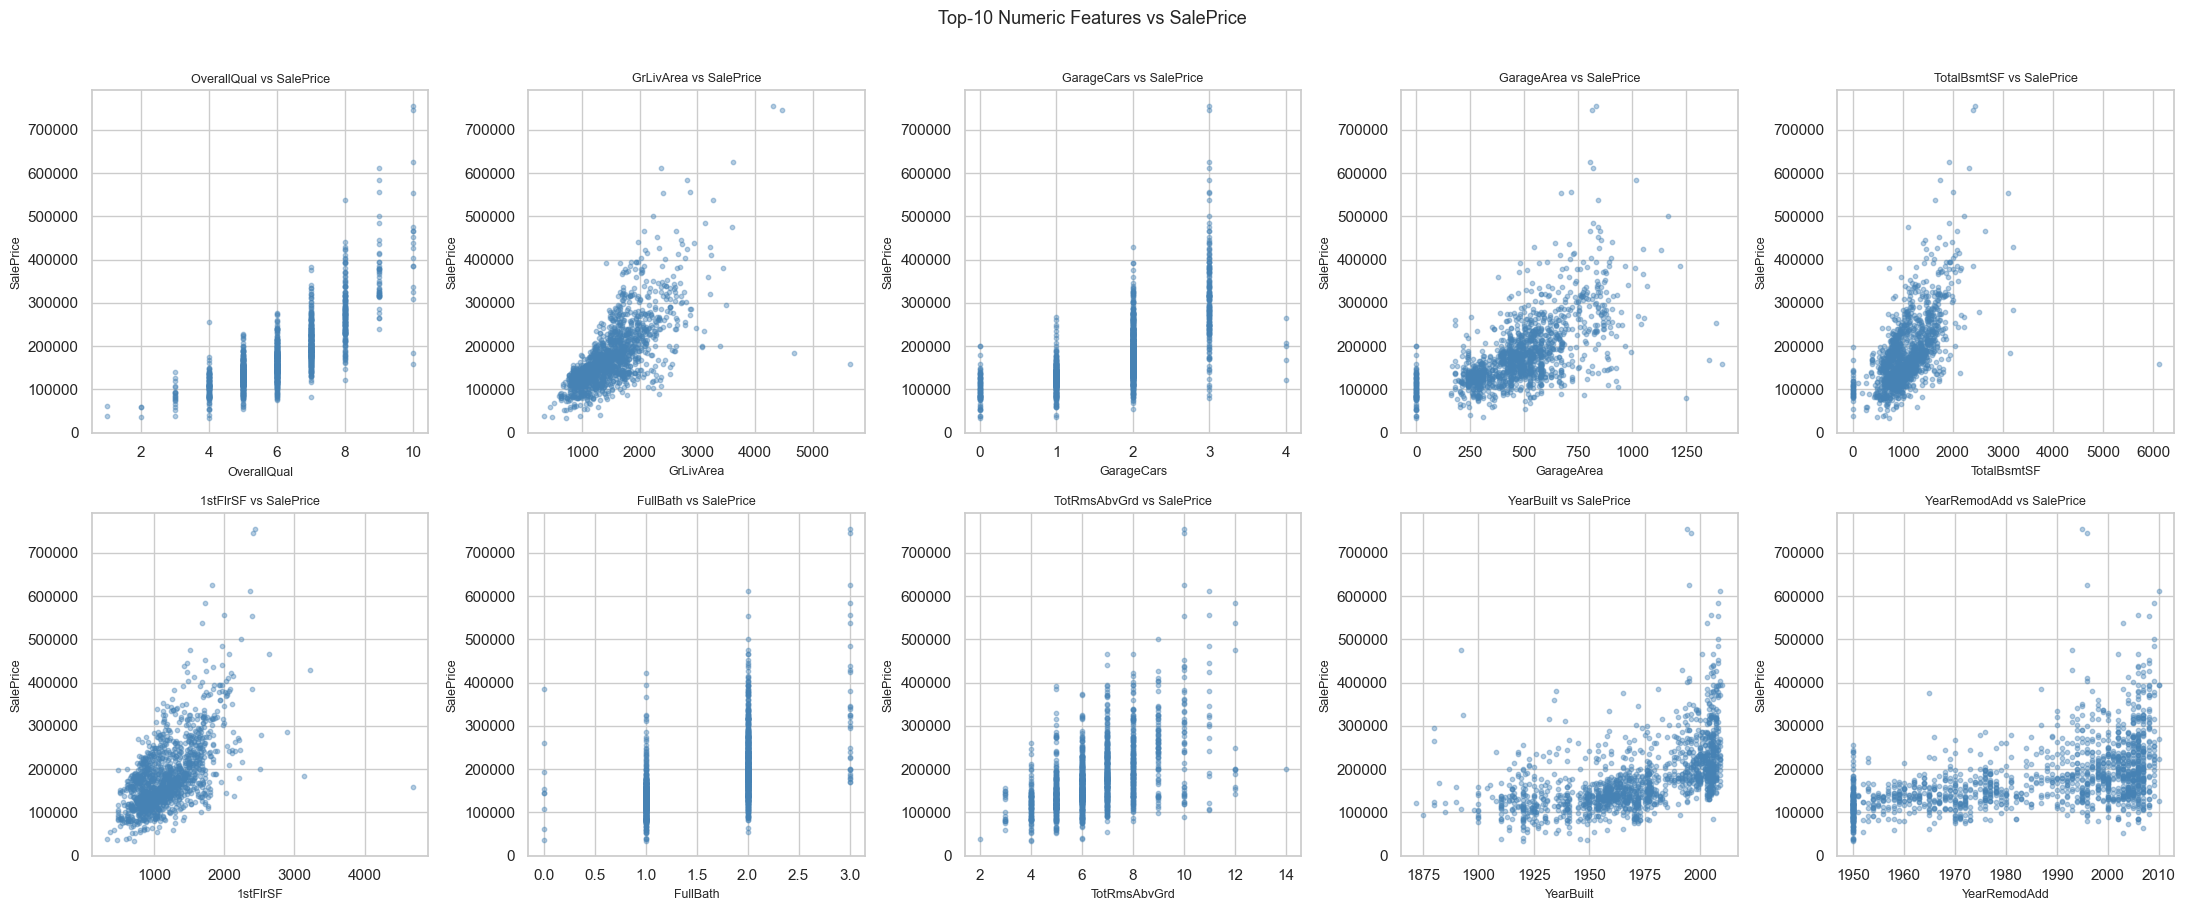

In [6]:
top_features = corr['SalePrice'].abs().sort_values(ascending=False)[1:11].index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for ax, feat in zip(axes.flatten(), top_features):
    ax.scatter(train[feat], train['SalePrice'], alpha=0.4, s=10, color='steelblue')
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('SalePrice', fontsize=9)
    ax.set_title(f'{feat} vs SalePrice', fontsize=9)
plt.suptitle('Top-10 Numeric Features vs SalePrice', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


## Categorial Data 

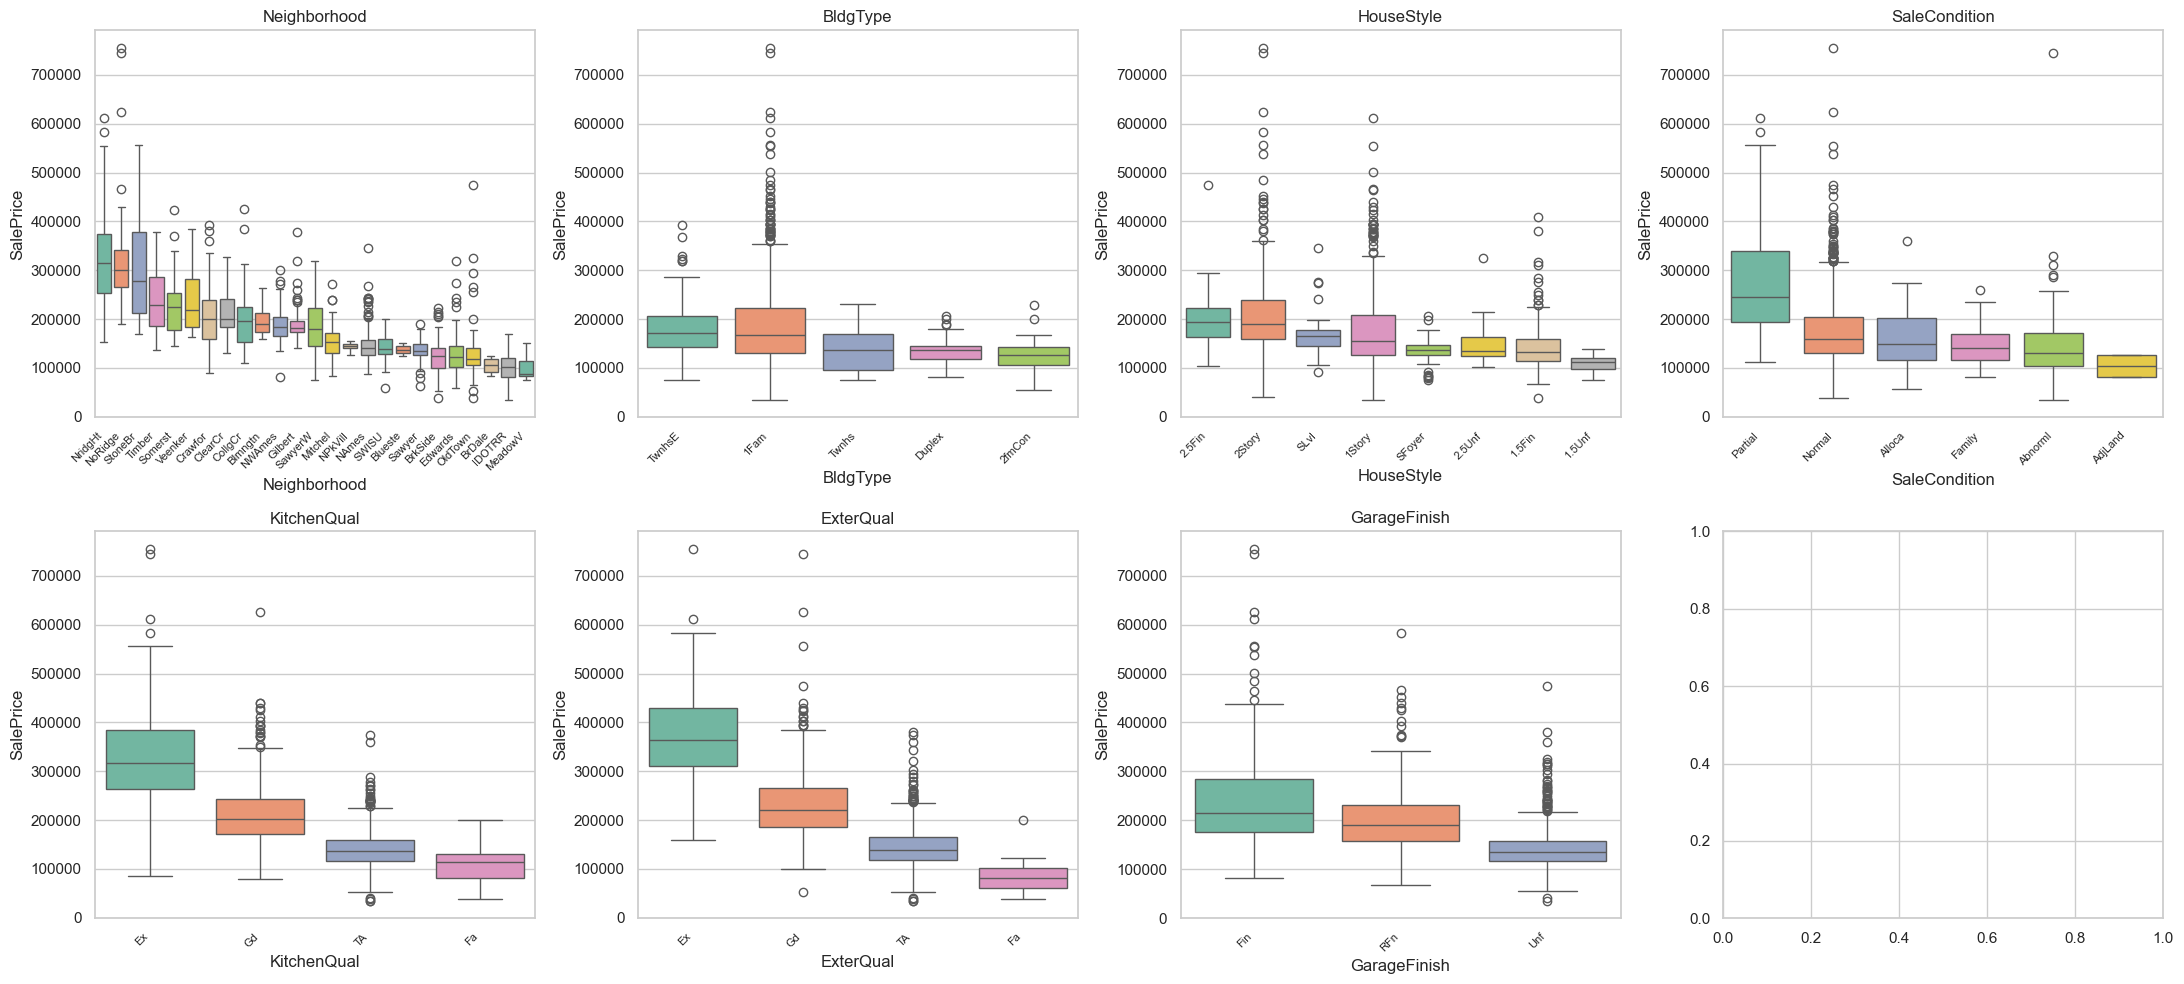

In [3]:
cat_cols = ['Neighborhood', 'BldgType', 'HouseStyle', 'SaleCondition',
            'KitchenQual', 'ExterQual', 'GarageFinish']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    order = train.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=col, y='SalePrice', order=order, ax=ax, palette='Set2')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Year column


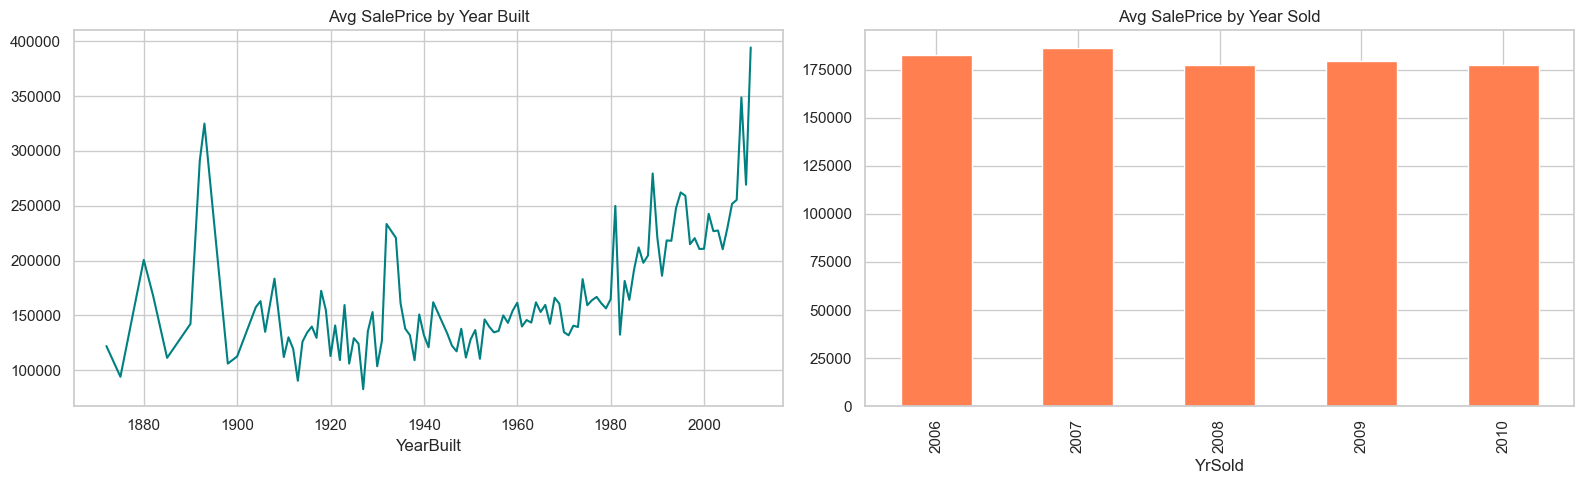

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
train.groupby('YearBuilt')['SalePrice'].mean().plot(ax=axes[0], color='teal')
axes[0].set_title('Avg SalePrice by Year Built')

train.groupby('YrSold')['SalePrice'].mean().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Avg SalePrice by Year Sold')
plt.tight_layout()
plt.show()

# Feature Engineering

In [3]:
df = train.copy()

# ── Log-transform target ──────────────────────────────────────────────────────
df['SalePrice'] = np.log1p(df['SalePrice'])

# ── Drop Id ───────────────────────────────────────────────────────────────────
df.drop('Id', axis=1, inplace=True)

# ── Fill missing values ───────────────────────────────────────────────────────
# Categorical: NaN means "None" for many features
none_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
             'GarageType','GarageFinish','GarageQual','GarageCond',
             'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
             'MasVnrType']
for c in none_cols:
    df[c] = df[c].fillna('None')

# Numeric: NaN → 0
zero_cols = ['GarageYrBlt','GarageArea','GarageCars',
             'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
             'BsmtFullBath','BsmtHalfBath','MasVnrArea']
for c in zero_cols:
    df[c] = df[c].fillna(0)

# LotFrontage: fill with median per Neighborhood
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

# Remaining
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
df['MSZoning']   = df['MSZoning'].fillna(df['MSZoning'].mode()[0])
df['Functional'] = df['Functional'].fillna('Typ')
df['Utilities']  = df['Utilities'].fillna(df['Utilities'].mode()[0])
df['SaleType']   = df['SaleType'].fillna(df['SaleType'].mode()[0])

print(f"Missing after fill: {df.isnull().sum().sum()}")

Missing after fill: 0


In [4]:
# ── New features ──────────────────────────────────────────────────────────────
df['TotalSF']        = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBath']      = (df['FullBath'] + 0.5*df['HalfBath'] +
                        df['BsmtFullBath'] + 0.5*df['BsmtHalfBath'])
df['TotalPorch']     = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                        df['3SsnPorch'] + df['ScreenPorch'] + df['WoodDeckSF'])
df['HouseAge']       = df['YrSold'] - df['YearBuilt']
df['RemodAge']       = df['YrSold'] - df['YearRemodAdd']
df['IsRemodeled']    = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)
df['HasGarage']      = (df['GarageArea'] > 0).astype(int)
df['HasPool']        = (df['PoolArea'] > 0).astype(int)
df['HasBasement']    = (df['TotalBsmtSF'] > 0).astype(int)
df['HasFireplace']   = (df['Fireplaces'] > 0).astype(int)
df['QualCond']       = df['OverallQual'] * df['OverallCond']
df['GrLivAreaQual']  = df['GrLivArea'] * df['OverallQual']

print("New features added. Shape:", df.shape)

New features added. Shape: (1460, 92)


In [5]:
# ── Fix skewed numeric features ───────────────────────────────────────────────
num_feats = df.select_dtypes(include=[np.number]).columns.drop('SalePrice')
skewed = df[num_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
high_skew = skewed[abs(skewed) > 0.75].index
df[high_skew] = np.log1p(df[high_skew].clip(lower=0))
print(f"Log-transformed {len(high_skew)} skewed features")


Log-transformed 28 skewed features


In [84]:
# ── Encode ordinal quality features ──────────────────────────────────────────

qual_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
             'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']


# ── Label encode remaining categoricals ──────────────────────────────────────
cat_remaining = df.select_dtypes(include='object').columns


In [86]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [87]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder , OrdinalEncoder ,OneHotEncoder

x_train ,x_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=SEED)

num_pipe = Pipeline([
    ('scaler',RobustScaler())
])

cat_pipe1= Pipeline([
    ('encode',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
    ])

cat_pipe2= Pipeline([
    ('encode',OneHotEncoder(drop='first',handle_unknown='ignore'))
    ])

preprocess = ColumnTransformer([
    ('encode',cat_pipe1,qual_cols),
    ('encode_label',cat_pipe2,cat_remaining),
    ('scale',num_pipe,num_cols)
],remainder='passthrough')

pipe = Pipeline([
    ('preprocess',preprocess),
    ('model',LinearRegression())
])

In [100]:
pipe.fit(x_train,y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encode', ...), ('encode_label', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [101]:
pred = pipe.predict(x_test)
score = r2_score(y_test, pred)
print (score)

0.8785383322538789


### Cross Validation Score

In [102]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    pipe,
    X,
    y,
    cv=5,
    scoring='r2',
    error_score='raise'
)

print(scores)

[0.90711262 0.88020389 0.88713464 0.90518652 0.82822081]


## Ridge Regression

In [93]:
from sklearn.linear_model import Ridge

pipe_ridge = Pipeline([
    ('preprocess', preprocess),
    ('model', Ridge(alpha=1.0))
])

In [94]:
pipe_ridge.fit(x_train,y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encode', ...), ('encode_label', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [95]:
p = pipe_ridge.predict(x_test)
print('Score',r2_score(y_test,p))

Score 0.8909397037891942


In [104]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline

lasso_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', Lasso(alpha=0.001))
])

lasso_pipe.fit(x_train, y_train)



,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encode', ...), ('encode_label', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [105]:
pred = lasso_pipe.predict(x_test)

print("R² Score:", r2_score(y_test, pred))

R² Score: 0.895559615016705


In [111]:

rf_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=500,
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=SEED,
        n_jobs=-1
    ))
])

rf_pipe.fit(x_train,y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encode', ...), ('encode_label', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [112]:
pred = rf_pipe.predict(x_test)

print("R² Score:", r2_score(y_test, pred))

R² Score: 0.8909146982098491


In [113]:
train_pred = rf_pipe.predict(x_train)
test_pred = rf_pipe.predict(x_test)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))

Train R²: 0.9834511654140347
Test R²: 0.8909146982098489


In [114]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features='sqrt',
        random_state=SEED,
        n_jobs=-1
    ))
])

In [115]:
rf_pipe.fit(x_train, y_train)

print("Train:", rf_pipe.score(x_train, y_train))
print("Test :", rf_pipe.score(x_test, y_test))

Train: 0.937119035739609
Test : 0.8778751961143336


# Choose the Linear Model , And deploy it 

In [117]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    pipe,
    x_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2'
)

importance_df = pd.DataFrame({
    'Feature': x_test.columns,
    'Importance': result.importances_mean
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(15))

          Feature  Importance
58    GarageYrBlt   30.182296
85      HasGarage   29.406917
70       PoolArea   25.008837
86        HasPool   21.834133
80      TotalBath    2.143873
48       FullBath    1.205176
46   BsmtFullBath    1.021532
45      GrLivArea    0.421989
16    OverallQual    0.331211
49       HalfBath    0.252144
90  GrLivAreaQual    0.214466
79        TotalSF    0.087281
47   BsmtHalfBath    0.055639
17    OverallCond    0.046414
71         PoolQC    0.035432


In [118]:
top_features = importance_df.head(15)['Feature'].tolist()
print(top_features)

['GarageYrBlt', 'HasGarage', 'PoolArea', 'HasPool', 'TotalBath', 'FullBath', 'BsmtFullBath', 'GrLivArea', 'OverallQual', 'HalfBath', 'GrLivAreaQual', 'TotalSF', 'BsmtHalfBath', 'OverallCond', 'PoolQC']


In [119]:
import pandas as pd

defaults = {}

for col in X.columns:
    
    if X[col].dtype == 'object':
        defaults[col] = X[col].mode()[0]
        
    else:
        defaults[col] = X[col].median()

print(defaults)

{'MSSubClass': np.float64(3.9318256327243257), 'MSZoning': np.float64(3.0), 'LotFrontage': np.float64(4.2626798770413155), 'LotArea': np.float64(9.156886838722746), 'Street': np.float64(1.0), 'Alley': np.float64(1.0), 'LotShape': np.float64(3.0), 'LandContour': np.float64(3.0), 'Utilities': np.float64(0.0), 'LotConfig': np.float64(4.0), 'LandSlope': np.float64(0.0), 'Neighborhood': np.float64(12.0), 'Condition1': np.float64(2.0), 'Condition2': np.float64(2.0), 'BldgType': np.float64(0.0), 'HouseStyle': np.float64(2.0), 'OverallQual': np.float64(6.0), 'OverallCond': np.float64(5.0), 'YearBuilt': np.float64(1973.0), 'YearRemodAdd': np.float64(1994.0), 'RoofStyle': np.float64(1.0), 'RoofMatl': np.float64(1.0), 'Exterior1st': np.float64(12.0), 'Exterior2nd': np.float64(13.0), 'MasVnrType': np.float64(2.0), 'MasVnrArea': np.float64(0.0), 'ExterQual': np.float64(3.0), 'ExterCond': np.float64(3.0), 'Foundation': np.float64(1.0), 'BsmtQual': np.float64(4.0), 'BsmtCond': np.float64(3.0), 'BsmtE

In [120]:
import pickle

with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(pipe, f)

In [121]:
import pickle

defaults = {}

for col in X.columns:
    if X[col].dtype == 'object':
        defaults[col] = X[col].mode()[0]
    else:
        defaults[col] = X[col].median()

with open("defaults.pkl", "wb") as f:
    pickle.dump(defaults, f)

In [122]:
y.name

'SalePrice'

In [123]:
y

0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1455    12.072547
1456    12.254868
1457    12.493133
1458    11.864469
1459    11.901590
Name: SalePrice, Length: 1460, dtype: float64

In [124]:
import pickle

with open("house_price_model.pkl", "rb") as f:
    model = pickle.load(f)

pred = model.predict(x_test.iloc[[0]])

print(pred)
print(np.expm1(pred))

[11.92510824]
[151010.04156163]


In [125]:
print("Training columns:", len(X.columns))

Training columns: 91


In [128]:
import pickle

template_row = X.iloc[[0]]

with open("template_row.pkl", "wb") as f:
    pickle.dump(template_row, f)

In [129]:
import pickle

template_row = X.iloc[[0]].copy()

with open("template_row.pkl", "wb") as f:
    pickle.dump(template_row, f)

In [130]:
import pickle
import numpy as np

with open("house_price_model.pkl", "rb") as f:
    model = pickle.load(f)

pred = model.predict(x_test.iloc[[0]])

print("Prediction:", pred[0])
print("Price:", np.expm1(pred[0]))
print("Actual y:", y_test.iloc[0])

Prediction: 11.925108236048429
Price: 151010.04156163242
Actual y: 11.947955847790901


In [131]:
print(X[["KitchenQual","ExterQual","GarageCond","HeatingQC"]].head())

   KitchenQual  ExterQual  GarageCond  HeatingQC
0            4          4           3          5
1            3          3           3          5
2            4          4           3          5
3            4          3           3          4
4            4          4           3          5


In [132]:
print(X["Neighborhood"].dtype)
print(X["Neighborhood"].head())
print(X["Neighborhood"].unique()[:10])

int64
0     5
1    24
2     5
3     6
4    15
Name: Neighborhood, dtype: int64
[ 5 24  6 15 11 21 14 17  3 19]
